## Çok sınıflı sınıflandırma (Multiclass classification)

* Önceki görevde ikili (binary) bir sınıflandırma problemini çözdük.  
* Peki ya **çok sınıflı (multiclass) bir sınıflandırma problemi**?

🎯 Egzersizin Amaçları:
- Çok sınıflı bir sınıflandırma problemi için tasarlanmış bir Sinir Ağı (Neural Network) yazmak
- Bu modelin ne kadar kolay **overfit** olabileceğini gözlemlemek… !

## (1) Bir `Blobs` veri kümesi oluşturun

📚 Sklearn’deki **`make_blobs`** fonksiyonu [(dokümantasyona bakınız)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) aşağıdakileri üretmenize olanak tanır:
- İstenilen sayıda veri örneği (`n_samples` parametresi)
- Her veri örneği için istenilen sayıda özellik (`n_features` parametresi)
- İstenilen sayıda sınıf/kategori (`centers` parametresi)
- Sınıflar arasındaki mesafe (`cluster_std` parametresi)

💡 Ayrıca, verinin **deterministik** olarak (aynı şekilde) üretilmesini ve tekrar edilebilir olmasını sağlayan `random_state` parametresi de vardır.


❓ Belgelere göre:

👽 Aşağıdakilerle bir ***blobs*** veri kümesi oluşturun:
- 1200 örnek
- Örnek başına 8 özellik
- 7 veri kategorisi
- Kategoriler arasındaki mesafe 8

🔮 1'e eşit bir `random_state` seçin.

📏 Şekli yazdırın ve `X` için (1200, 8) ve `y` için (1200,) ile eşleştiğini kontrol edin ❓

In [1]:
from sklearn.datasets import make_blobs

# Parametreleri belirleyelim
X, y = make_blobs(
    n_samples=1200,      # Toplam örnek sayısı
    n_features=8,        # Örnek başına özellik sayısı
    centers=7,           # Kategori (sınıf) sayısı
    cluster_std=8,       # Sınıflar arası mesafe/yayılım (8 oldukça geniş bir yayılım!)
    random_state=1       # Sonuçların her seferinde aynı çıkması için
)

# Şekilleri kontrol edelim
print(f"X şekli (Özellikler): {X.shape}") # (1200, 8) bekliyoruz
print(f"y şekli (Etiketler): {y.shape}")   # (1200,) bekliyoruz

X şekli (Özellikler): (1200, 8)
y şekli (Etiketler): (1200,)


❓ _matplotlib_ kullanarak bu blob veri kümesinin iki (rastgele) boyutunun dağılım grafiğini çizin. Her nokta, ait olduğu kategoriye göre renklendirilmelidir. ❓

AttributeError: module 'matplotlib.pyplot' has no attribute 'add_artist'

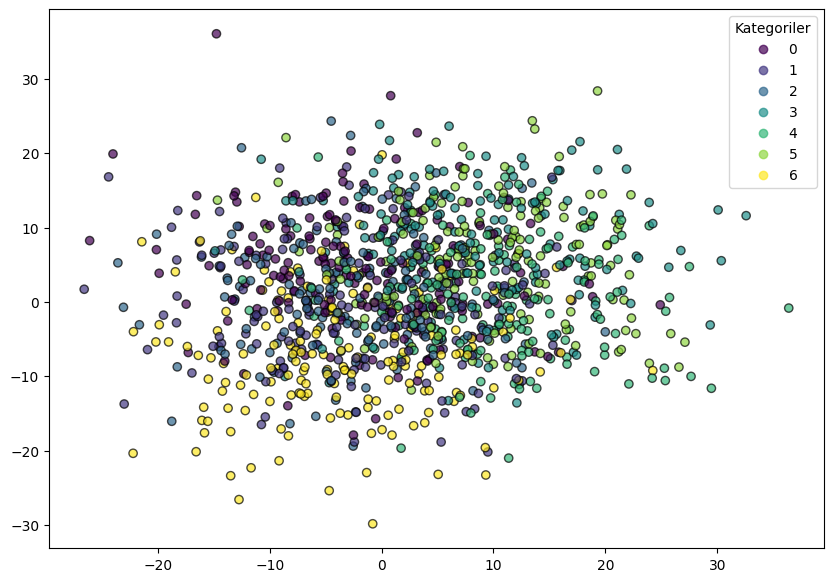

In [2]:
import matplotlib.pyplot as plt

# Rastgele iki boyut seçelim (örneğin ilk iki özellik: 0 ve 1)
dim1 = 0
dim2 = 1

# Grafiği oluşturalım
plt.figure(figsize=(10, 7))  # Grafiğin boyutu

# Dağılım grafiği (scatter plot)
# X[:, dim1]: Seçtiğimiz ilk boyutun tüm verileri
# X[:, dim2]: Seçtiğimiz ikinci boyutun tüm verileri
# c=y: Noktaları kategorilerine (y etiketlerine) göre renklendirir
# cmap='viridis': Renk paleti (7 sınıf için güzel bir ayrım sunar)
# alpha=0.7: Noktaların hafif şeffaf olması, üst üste binmeleri görmeyi sağlar
scatter = plt.scatter(X[:, dim1], X[:, dim2], c=y, cmap='viridis', edgecolors='k', alpha=0.7)

# Renklerin hangi kategoriye ait olduğunu gösteren lejant (açıklama)
legend = plt.legend(*scatter.legend_elements(), title="Kategoriler")
plt.add_artist(legend)

# Eksen etiketleri ve başlık
plt.xlabel(f"Özellik {dim1}")
plt.ylabel(f"Özellik {dim2}")
plt.title(f"Blob Veri Kümesi Dağılımı ({dim1}. ve {dim2}. Boyutlar)")
plt.grid(True, linestyle='--', alpha=0.5) # Arka plana hafif ızgara ekleyelim

plt.show() # Grafiği göster

❓ Diğer boyutlarda da aynı işlemi tekrarlayın. Veri noktalarının kolayca ayrılmadığını görsel olarak görebilirsiniz ❓

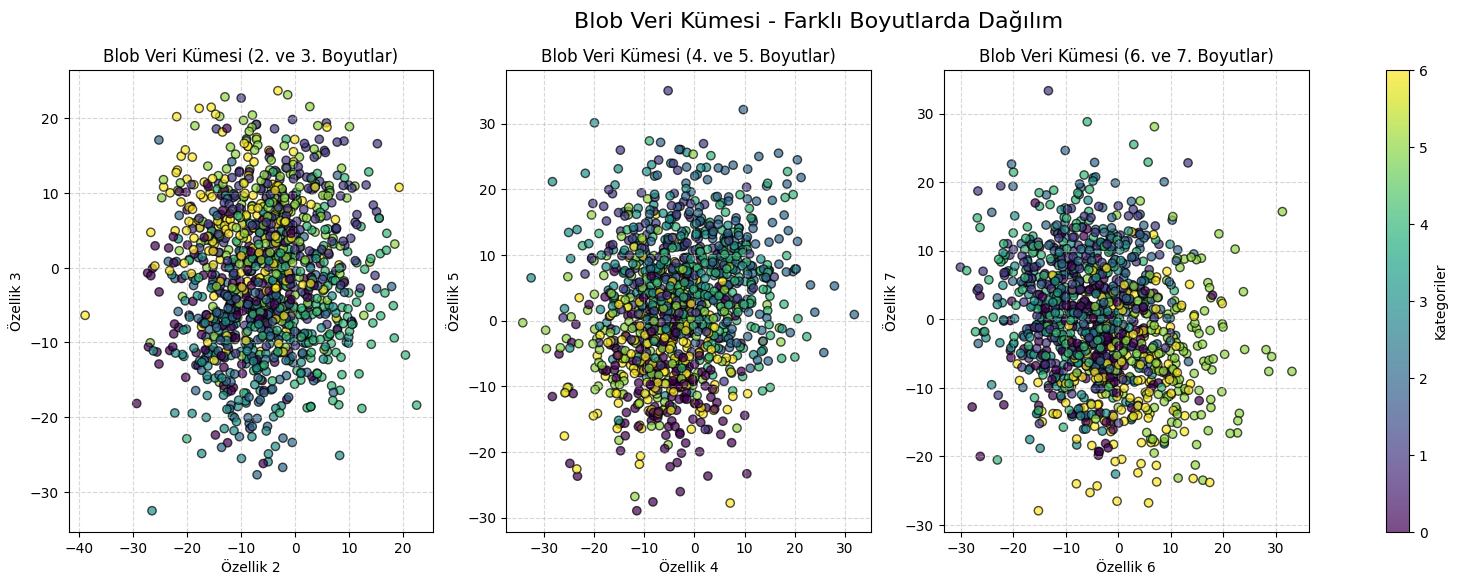

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Blob veri kümesini oluşturmuştuk (tekrar etmeye gerek yok)

# Grafikleri tek bir figürde göstermek için subplot kullanalım
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# Boyut kombinasyonlarını belirleyelim
dim_combinations = [(2, 3), (4, 5), (6, 7)]

for i, (dim1, dim2) in enumerate(dim_combinations):
    # Her bir subplot için dağılım grafiği
    ax = axes[i]
    scatter = ax.scatter(X[:, dim1], X[:, dim2], c=y, cmap='viridis', edgecolors='k', alpha=0.7)
    
    # Eksen etiketleri ve başlık
    ax.set_xlabel(f"Özellik {dim1}")
    ax.set_ylabel(f"Özellik {dim2}")
    ax.set_title(f"Blob Veri Kümesi ({dim1}. ve {dim2}. Boyutlar)")
    ax.grid(True, linestyle='--', alpha=0.5)

# Renk lejantını figüre ekleyelim
fig.colorbar(scatter, ax=axes.ravel().tolist(), label="Kategoriler")

plt.suptitle("Blob Veri Kümesi - Farklı Boyutlarda Dağılım", fontsize=16)
plt.show()

## (2) Çok sınıflı sınıflandırma probleminin hedefini kodlama

👉 Şu an için hedef `y`, giriş verisinin ait olduğu kategoriyi temsil eden **tamsayılar listesidir**. Şöyle görünür:  
`[3, 2, 2, 3, 0, 5, 1, 1, 0, 5, ...]`  
(bu örnekte 0’dan 6’ya kadar **7 kategori** vardır).

🧑🏻‍🏫 Ancak **Tensorflow/Keras’ta kategorik problemler için hedef/çıktı (`target/output`) aşağıdaki şekilde encode edilmelidir**:

```
[
[0, 0, 0, 1, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[1, 0, 0, 0, 0, 0, 0], 
[0, 0, 0, 0, 0, 1, 0], 
[0, 1, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1],
...
]
```


Burada:
- satır sayısı, **gözlem sayısına** eşittir  
- sütun sayısı, **farklı kategori sayısına** eşittir  

👉 Her sütun bir **kategoriyi** temsil eder.  

👉 Her satır bir **hedefi** temsil eder; `1` değeri, giriş verisinin ait olduğu kategoriyi gösterir.  

Bir satırı, olasılık vektörü olarak düşünebilirsiniz.

```
Örnek:
| Cat 0 | Cat 1 | Cat 2 | Cat 3 | Cat 4 | Cat 5 | Cat 6 |
|-------|-------|-------|-------|-------|-------|-------|
| 0     | 0     | 0     | 1     | 0     | 0     | 0     |

Bu, ilgili satırın %100 olasılıkla Cat 3’e ait olduğu anlamına gelir.
Cat 3
```


---

💡 `y`’yi kategorik hale dönüştürmek için **Tensorflow/Keras içindeki `to_categorical`** fonksiyonunu kullanın.

<details>
    <summary><i>Tensorflow/Keras’taki <code>to_categorical</code> ile Scikit-Learn’deki <code>OneHotEncoder</code> arasında bir benzerlik var mı?</i></summary>

Evet! **`to_categorical`**, Sklearn’deki `OneHotEncoder` gibi çalışır;  
ancak burada bir **kategorik feature** değil, **kategorik target (hedef)** encode edilir.

</details>

---

❓ **Kategorik hedefin kodlanması**:  `y` yazdırın, ardından *to_categorical* işlevini *`y`* üzerinde uygulayın ve *y'nin kategorize edilmiş halini* `y_cat` adlı bir değişkene kaydedin. ❓

In [4]:
from tensorflow.keras.utils import to_categorical

# Orijinal y'nin ilk 5 değerine bakalım
print(f"Orijinal y (ilk 5): {y[:5]}")

# to_categorical ile dönüşüm
y_cat = to_categorical(y, num_classes=7)

# Dönüştürülmüş y_cat'in ilk 5 satırına bakalım
print("\ny_cat (One-Hot Encoded - ilk 5 satır):")
print(y_cat[:5])

# Şekilleri kontrol edelim
print(f"\ny_cat şekli: {y_cat.shape}") # (1200, 7) olmalı

2026-04-07 20:55:46.354484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Orijinal y (ilk 5): [2 2 5 1 2]

y_cat (One-Hot Encoded - ilk 5 satır):
[[0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]]

y_cat şekli: (1200, 7)


## (3) Çok Sınıflı Sınıflandırma Görevi için Sinir Ağı

❓ **Hold-out yöntemi**: Veri kümesi $X$ ve $y_{cat}$ 'i _train_ ve _test_ kümelerine ayırın (boyut: 70/30%)

Not: Değişkenleri `X_train`, `X_test`, `y_train` ve `y_test` olarak adlandırın ❓

In [5]:
from sklearn.model_selection import train_test_split

# Veriyi %70 Eğitim ve %30 Test olacak şekilde ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X,           # Giriş özellikleri (1200, 8)
    y_cat,       # One-hot encoded hedefler (1200, 7)
    test_size=0.3, # %30 test verisi
    random_state=1 # Sonuçların tekrarlanabilir olması için (Önemli!)
)

# Boyutları kontrol ederek her şeyin yolunda olduğundan emin olalım
print(f"Eğitim seti (X_train) boyutu: {X_train.shape}") # (840, 8) bekliyoruz
print(f"Test seti (X_test) boyutu: {X_test.shape}")     # (360, 8) bekliyoruz
print(f"Eğitim etiketleri (y_train) boyutu: {y_train.shape}") # (840, 7) bekliyoruz

Eğitim seti (X_train) boyutu: (840, 8)
Test seti (X_test) boyutu: (360, 8)
Eğitim etiketleri (y_train) boyutu: (840, 7)


Derin Öğrenmede, herhangi bir Makine Öğrenimi algoritmasında olduğu gibi, sayısal özellikleriniz ölçeklendirilmelidir.

❓ **Ölçeklendirme**: Eğitim kümesine bir Sklearn [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) uydurun ve hem eğitim kümenizi hem de test kümenizi dönüştürün ❓

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Scaler nesnesini oluştur
scaler = StandardScaler()

# 2. EĞİTİM verisinden istatistikleri öğren ve dönüştür (Tek bir 'fit')
X_train_scaled = scaler.fit_transform(X_train)

# 3. TEST verisini ise eğitimden öğrendiğin bilgilerle dönüştür
X_test_scaled = scaler.transform(X_test)

# Kontrol edelim (Ortalama 0, Standart Sapma 1 civarı olmalı)
print(f"Ölçeklenmiş X_train ortalaması: {X_train_scaled.mean():.2f}")
print(f"Ölçeklenmiş X_train standart sapması: {X_train_scaled.std():.2f}")

Ölçeklenmiş X_train ortalaması: 0.00
Ölçeklenmiş X_train standart sapması: 1.00


❓ **Modeli başlatma**: Aşağıdaki işlevi tamamlayarak aşağıdaki özelliklere sahip bir model oluşturun/başlatın:
- İlk katman:
   - 50 nöron
   - `relu` aktivasyonu
   - Doğru giriş boyutu
- Çıkış katmanı:
   - Çok sınıflı sınıflandırma görevi için tasarlanmış
   - Her sınıfa ait olma olasılıklarını çıktı olarak veren ❓

In [8]:
from tensorflow.keras import Sequential, layers

def initialize_model():

    #############################
    #  1 - Model mimarisi       #
    #############################

    model = Sequential()
    
    # İlk gizli katman: 50 nöron, ReLU aktivasyonu ve 8 giriş özelliği
    model.add(layers.Dense(50, activation='relu', input_shape=(8,)))
    
    # Ara katman eklemek istersen buraya ekleyebilirsin, 
    # ama görevde belirtilen minimum yapıya göre devam edelim:
    
    # Çıkış katmanı: 7 sınıfımız olduğu için 7 nöron
    # Aktivasyon: Çok sınıflı olasılıklar için 'softmax'
    model.add(layers.Dense(7, activation='softmax'))

    #############################
    #  2 - Optimizasyon Yöntemi #
    #############################
    model.compile(
        loss='categorical_crossentropy', # Çok sınıflı (Multi-class) için standart
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# Modeli oluşturma
model = initialize_model()

# Mimarinin görsel özetini görelim
model.summary()

/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807 (3.15 KB)

 Trainable params: 807 (3.15 KB)

 Non-trainable params: 0 (0.00 B)

❓  Modelde kaç parametre (diğer adıyla ağırlık) vardır? ❓

In [ ]:
807

❓ **Modeli uydurma**: Modelinizi 50 dönemlik tren verilerine uydurun ve geçmişi çizin ❓

In [9]:
# Modeli eğitme
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=50,           # 50 dönem (tur)
    batch_size=16,       # Her adımda 16 örnek görsün
    validation_split=0.2, # Eğitimin %20'sini anlık kontrol için ayır
    verbose=1            # Eğitim sürecini ekranda göster
)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2753 - loss: 1.8012 - val_accuracy: 0.2560 - val_loss: 1.7747
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4301 - loss: 1.5413 - val_accuracy: 0.3929 - val_loss: 1.5411
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5521 - loss: 1.3500 - val_accuracy: 0.4762 - val_loss: 1.3544
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6458 - loss: 1.2016 - val_accuracy: 0.5833 - val_loss: 1.2032
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6696 - loss: 1.0857 - val_accuracy: 0.6250 - val_loss: 1.0907
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6741 - loss: 0.9999 - val_accuracy: 0.6429 - val_loss: 1.0033
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6845 - loss: 0.9352 - val_accuracy: 0.6726 - val_loss: 0.9435
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6920 - loss: 0.8874 - val_accuracy: 0.6786 - val_loss:

❓ **Değerlendirme**:  Modelinizi test setinde değerlendirin ve doğruluğu yazdırın ❓

In [10]:
# Modelin test seti üzerindeki performansını ölçelim
results = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Kaybı (Loss): {results[0]:.4f}")
print(f"Test Doğruluğu (Accuracy): %{results[1]*100:.2f}")

Test Kaybı (Loss): 0.9753
Test Doğruluğu (Accuracy): %67.50


❓ 🤔 Bu iyi bir puan mı? Bunu bir tür karşılaştırma değeriyle karşılaştırmalısınız. Bu durumda, rastgele bir tahminle ne kadar puan elde edilebilir? Bu temel puanı `accuracy_baseline` değişkeninde saklayın. ❓

(Bunun için kod yazmanıza gerek yok, sadece veri setimizin nasıl oluşturulduğunu düşünün.)

In [12]:
accuracy_baseline = 0.1428

🧪 **Kodunu Test Et**

In [13]:
from nbresult import ChallengeResult
result = ChallengeResult('baseline',
                         accuracy=accuracy_baseline)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/erdincuyar/Desktop/code/erdincuyar/S18D2-S-Data-multiclass-classification/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_baseline.py::TestBaseline::test_accuracy PASSED                     [100%]

============================== 1 passed in 0.03s ===============================


💯 You can commit your code:

git add tests/baseline.pickle

git commit -m 'Completed baseline step'

git push origin master



❗ 👀 Bekle ... Kayıp grafiğine daha yakından bakarsan, 50 dönemden sonra da kayıp hala azalmaya devam ediyor gibi görünüyor. Neden bu kadar erken durduruyorsun ❓❗

❓ Modeli yeniden başlatıp bu sefer 1000 dönemle tekrar çalıştıralım ve geçmişi tekrar grafiğe çizelim. ❓

1000 Epoch'luk eğitim tamamlandı!


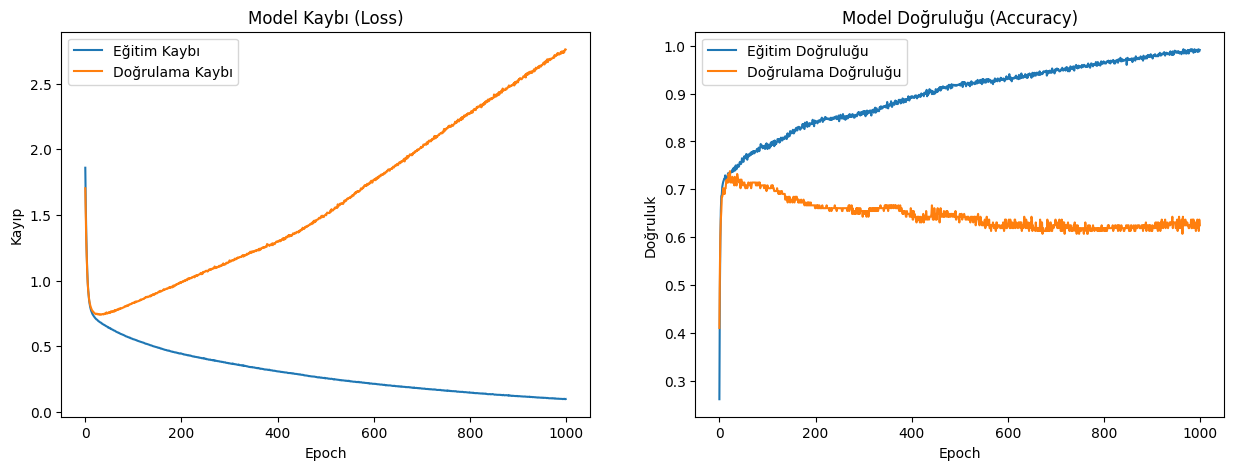

In [15]:
# 1. Modeli sıfırdan başlatalım (temiz bir sayfa)
model = initialize_model()

# 2. 1000 epoch boyunca eğitelim
# verbose=0 yaparak ekranı binlerce satırla doldurmayalım, ama eğitimi bekleyelim
history_1000 = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=1000, 
    batch_size=16, 
    validation_split=0.2, 
    verbose=0 
)

print("1000 Epoch'luk eğitim tamamlandı!")

# 3. Geçmişi tekrar çizdirelim
import matplotlib.pyplot as plt

def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. Kayıp (Loss) Grafiği
    ax[0].plot(history.history['loss'], label='Eğitim Kaybı')
    ax[0].plot(history.history['val_loss'], label='Doğrulama Kaybı')
    ax[0].set_title('Model Kaybı (Loss)')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Kayıp')
    ax[0].legend()
    
    # 2. Doğruluk (Accuracy) Grafiği
    ax[1].plot(history.history['accuracy'], label='Eğitim Doğruluğu')
    ax[1].plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
    ax[1].set_title('Model Doğruluğu (Accuracy)')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Doğruluk')
    ax[1].legend()
    
    plt.show()

# Şimdi tekrar çizdirebiliriz
plot_history(history_1000)

❓ **Bir modeli daha uzun süre eğitirken...** ❓
- Yeni kayıp hakkında ne söyleyebilirsiniz?
- Modelinizi test setinde bir kez daha değerlendirin ve doğruluğu yazdırın.

In [17]:
# 1000 Epoch sonrası test performansı (model ismine dikkat: model)
results_1000 = model.evaluate(X_test_scaled, y_test, verbose=0)

print("-" * 40)
print(f"Test Kaybı (1000 Epoch Sonrası): {results_1000[0]:.4f}")
print(f"Test Doğruluğu (1000 Epoch Sonrası): %{results_1000[1]*100:.2f}")

# Karşılaştırma için başlangıç (baseline) değerini de tekrar hatırlayalım
accuracy_baseline = 1/7
print(f"Rastgele Tahmin Başarısı (Baseline): %{accuracy_baseline*100:.2f}")
print("-" * 40)

----------------------------------------
Test Kaybı (1000 Epoch Sonrası): 3.5042
Test Doğruluğu (1000 Epoch Sonrası): %56.11
Rastgele Tahmin Başarısı (Baseline): %14.29
----------------------------------------


* 😁 Tren setinde hesaplanan kayıp, 50 epok ile karşılaştırıldığında 1000 epok ile daha küçük görünüyor.
* 😟 Anc ak test setindeki doğruluk, 50 epok ile karşılaştırıldığında 1000 epok ile daha kötü...

❓ Bu fenomene ne denir? ❓

> aşırı öğrenme

---

🤔 Bunun olmasını önlemek için ne yapmalıyız? 

<details>
    <summary><i>Olası seçenekler</i></summary>
    

⚠️ Sinir ağlarında aşırı uyumun olmasını önlemek için, örneğin şunları yapabiliriz:
1. Sinir ağının gürültülü veri noktalarından çok fazla öğrenmesini önlemek için ***makul sayıda dönem*** seçin
2. ***Erken Durdurma*** kriteri, yani _.fit()_ 📆 cf. ***Derin Öğrenme > Optimize Ediciler, Kayıp, Uydurma***

</details>    

---


❓ Test kaybının pratikte ne zaman tekrar artmaya başladığını görsel olarak kontrol edelim.  Aşağıdaki komutu çalıştırın ve geçmişi çizin❓

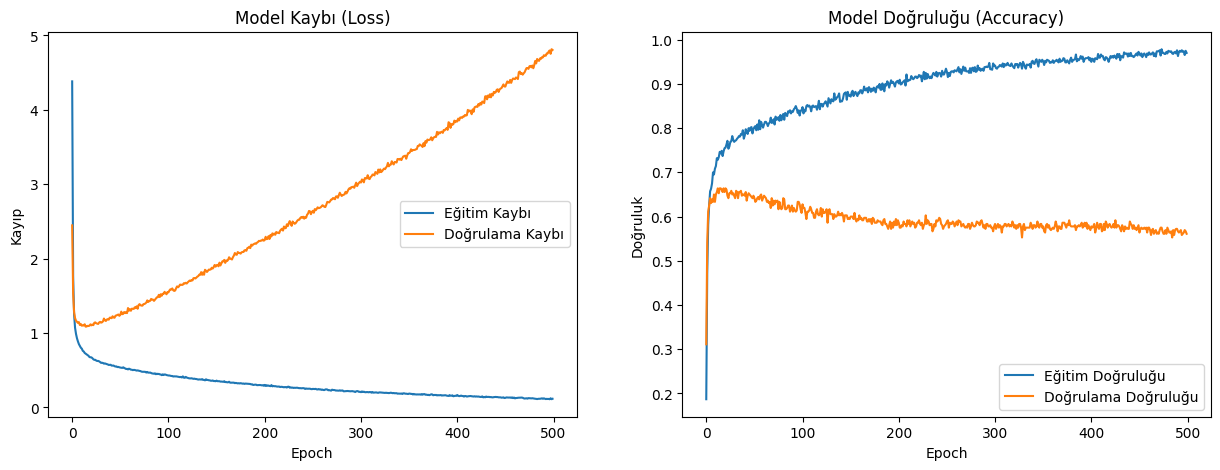

In [18]:
model = initialize_model()

history = model.fit(X_train,
                    y_train,
                    validation_data=(X_test, y_test),
                    epochs=500,
                    batch_size=16,
                    verbose=0)
plot_history(history)

😱 Ama durun... test setini kullanırsak hile yapmış olmaz mıyız? Evet, oluruz. Ama yine sabırlı olun. ***Derin Öğrenme - Optimize Ediciler, Kayıp, Uydurma*** bölümünde, bunu önlemek için ***Doğrulama Seti*** adını verdiğimiz şeyi kullanacağız!

🧘🏻‍♀️ Şimdilik, sonraki sorulara geçelim!

❓ **Ağı değerlendirme**: <span style="color:blue">eğitim seti</span> ve <span style="color:orange">test seti</span> üzerindeki kayıp ve doğruluk değerlerini grafik olarak gösterin. Bu konuda ne söyleyebilirsiniz? ❓ 

In [19]:
def plot_loss_accuracy(history):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

In [ ]:
# SENİN KODUN BURAYA

🤔 Derin Öğrenme modelimiz neden bu kadar kolay aşırı uyum sağlıyor?

😳 Düşünün, sinir ağımız sadece 8 özellik içeren bir veri kümesinden basit bir sınıflandırma görevi için ~800 parametre öğrenmek zorunda! Üstelik, uyum sağlamak için toplamda sadece ~800 veri noktamız var! Model, eğitim kümesindeki her noktanın tam sınıfını neredeyse “öğrenebilir”. 

Buna karşılık, basit bir Lojistik Regresyon, bu blob veri kümesinin kalıplarını yakalamak için sadece 9 parametreyi öğrenmek zorunda kalırdı! 

😏 Derin öğrenme etkileyici bir kavramdır, ancak basit makine öğrenimi görevleri için açıkça aşırı ve gereksiz bir seçenek olabilir!

⭐️ Aşağıdakiler için son derece yararlı olacaktır:
- 📸 Görüntü işleme
- 💹 Zaman serileri
- 🗣 Doğal dil işleme

---

🏁 Tebrikler!

💾 Not defterinizi `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki göreve geçin!